In [48]:
import polars as pl
import torch

from hakken_models.core.entities.kg_data import KGData
from hakken_models.core.entities.kg_data_with_preds import KGDataWithPreds
from hakken_models.core.entities.temporal_kg_data import TemporalKGData
from hakken_models.data_loaders.kg_link_neighbor_loader import KGLinkNeighborLoader
from hakken_models.models.thiger import THiGER
from hakken_models.render.plots import plot_temporal_kg

In [49]:
data_config = {"num_entities": 10, "num_relations": 3, "num_timestamps": 2, "num_domains": 10}
gnn_config = {
    "name": "GraphSAGE",
    "kwargs": {"hidden_channels": 64, "num_layers": 2},
}

transformer_config = {
    "name": "Transformer",
    "kwargs": {
        "num_heads": 4,
        "num_layers": 1,
        "dropout": 0.0,
        "use_pos_encoding": False,
        "aggregation": "cls_token",
    },
}

thiger_config = {
    "entity_embedding_dim": 16,
    "relation_embedding_dim": 16,
    "has_logits": True,
    "domain_embedding_dim": None,
}
num_domains = data_config.get("num_domains")
domain_embedding_dim = thiger_config.get("domain_embedding_dim")
if num_domains is None:
    domain_embedding_dim = None

device = "cpu"

In [50]:
domains_mapping_df: pl.DataFrame | None = None
num_entities = data_config["num_entities"]

if num_domains is not None:
    node_ids = list(range(num_entities))
    domains = [node_id % num_domains for node_id in node_ids]
    domains_mapping_df = pl.DataFrame({"node_id": node_ids, "domain_id": domains})

facts = torch.tensor(
    [
        [0, 1, 3, 0],
        [3, 0, 5, 1],
        [5, 1, 3, 0],
        [8, 2, 5, 0],
    ],
    dtype=torch.long,
    device=device,
)

domains_mapping_df: pl.DataFrame | None = None
if num_domains is not None:
    node_ids = list(range(num_entities))
    domains = [node_id % num_domains for node_id in node_ids]
    domains_mapping_df = pl.DataFrame({"node_id": node_ids, "domain_id": domains})
    print(domains_mapping_df)

kg_data = KGData.from_facts(
    facts=facts,
    domains_mapping_df=domains_mapping_df,
    num_nodes=num_entities,
    num_domains=num_domains,
    relabel_nodes=False,
)


kg_data.print_summary()

shape: (10, 2)
┌─────────┬───────────┐
│ node_id ┆ domain_id │
│ ---     ┆ ---       │
│ i64     ┆ i64       │
╞═════════╪═══════════╡
│ 0       ┆ 0         │
│ 1       ┆ 1         │
│ 2       ┆ 2         │
│ 3       ┆ 3         │
│ 4       ┆ 4         │
│ 5       ┆ 5         │
│ 6       ┆ 6         │
│ 7       ┆ 7         │
│ 8       ┆ 8         │
│ 9       ┆ 9         │
└─────────┴───────────┘
x:
tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]])

edge_index:
tensor([[0, 3, 5, 8],
        [3, 5, 3, 5]])

edge_attr:
tensor([[1, 0],
        [0, 1],
        [1, 0],
        [2, 0]])
KGData(x=[10, 1], edge_index=[2, 4], edge_attr=[4, 2], num_nodes=10)


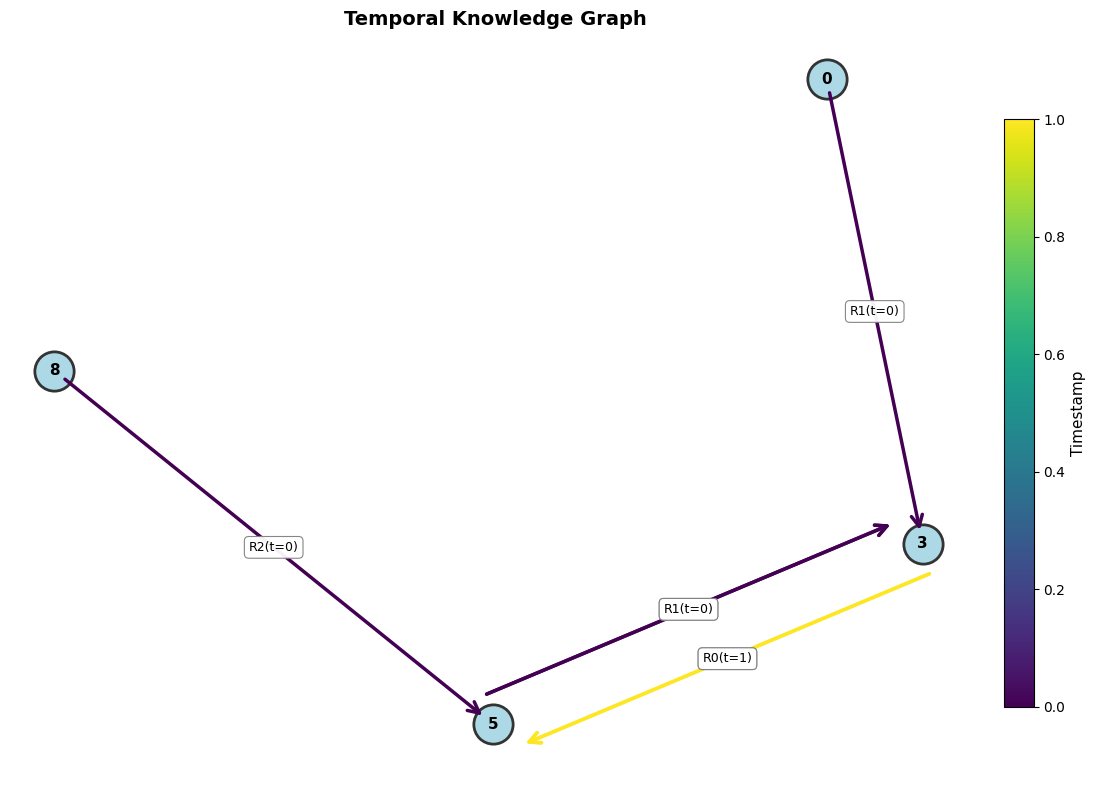

In [51]:
plot_temporal_kg(facts=facts)

In [52]:
temporal_kg = TemporalKGData(kg_data)

In [53]:
thiger = THiGER(
    num_entities=data_config["num_entities"],
    num_relations=data_config["num_relations"],
    num_timestamps=data_config["num_timestamps"],
    gnn_name=gnn_config["name"],
    gnn_kwargs=gnn_config["kwargs"],
    transformer_name=transformer_config["name"],
    transformer_kwargs=transformer_config["kwargs"],
    has_logits=thiger_config["has_logits"],
    entity_embedding_dim=thiger_config["entity_embedding_dim"],
    relation_embedding_dim=thiger_config["relation_embedding_dim"],
    domain_embedding_dim=domain_embedding_dim,
    num_domains=num_domains,
).to(device)

In [54]:
kg_data.edge_index

tensor([[0, 3, 5, 8],
        [3, 5, 3, 5]])

In [67]:
edge_label_index = kg_data.edge_index
edge_label = kg_data.edge_attr[:, [0]]


loader = KGLinkNeighborLoader(
    data=kg_data,
    num_neighbors=[3, 3],
    batch_size=2,
    edge_label_index=edge_label_index,
    edge_label=edge_label,
    shuffle=False,
)

batch: KGDataWithPreds
for batch in iter(loader):
    batch.print_summary()
    print("-----------------------")

x:
tensor([[0],
        [3],
        [5],
        [8]])

edge_index:
tensor([[0, 2, 1, 3],
        [1, 1, 2, 2]])

edge_attr:
tensor([[1, 0],
        [1, 0],
        [0, 1],
        [2, 0]])

n_id:
tensor([0, 3, 5, 8])

e_id:
tensor([0, 2, 1, 3])

input_id:
tensor([0, 1])

edge_label_index:
tensor([[0, 1],
        [1, 2]])

edge_label:
tensor([[1],
        [0]])
KGData(x=[4, 1], edge_index=[2, 4], edge_attr=[4, 2], num_nodes=4, n_id=[4], e_id=[4], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[2], edge_label_index=[2, 2], edge_label=[2, 1])
-----------------------
x:
tensor([[3],
        [5],
        [8],
        [0]])

edge_index:
tensor([[3, 1, 0, 2],
        [0, 0, 1, 1]])

edge_attr:
tensor([[1, 0],
        [1, 0],
        [0, 1],
        [2, 0]])

n_id:
tensor([3, 5, 8, 0])

e_id:
tensor([0, 2, 1, 3])

input_id:
tensor([2, 3])

edge_label_index:
tensor([[1, 2],
        [0, 1]])

edge_label:
tensor([[1],
        [2]])
KGData(x=[4, 1], edge_index=[2, 4], edge_attr=[4, 2], n

In [60]:
batch.n_id[batch.edge_label_index]

tensor([[0],
        [5]])

In [28]:
temporal_kg = TemporalKGData(batch)

In [30]:
kg_i = temporal_kg.get_timestamp_data(1, relabel_nodes=True)
kg_i

TimestampSubgraphData(node_data=tensor([[3],
        [5]]), n_id=tensor([3, 5]), edge_index=tensor([[0],
        [1]]), edge_attr=tensor([[0, 1]]))